# Seasonality data exploration: UN all-years export + HMD STMF weekly series

The globe's live pipeline (`scripts/build-seasonality.mjs`) currently builds seasonal
death-rate curves from a **single UN export snapshot** (49 countries, mostly just the
latest 1-2 years each) — only 27 of those pass the quality gate and get a direct curve;
everyone else falls back to a latitude-scaled approximation.

This notebook explores two richer sources that arrived after that pipeline was built,
to see whether they're worth folding in:

1. **`seasonality-all-years.csv`** — the same UN Demographic Yearbook export, but for
   *all* available years per country (up to 46 years, 141 countries) instead of a
   single snapshot. More years per country -> more stable curves and more countries
   clearing the "at least one complete year" gate.
2. **`stmf.xlsx`** — the Human Mortality Database's *Short-Term Mortality Fluctuations*
   series: **weekly** all-cause deaths, sex and age split, 2000-present, for 38
   countries/regions — including several big countries the UN export doesn't cover at
   all (USA, France, England & Wales, Poland, South Korea, Taiwan, Chile, Australia,
   Canada, Greece, Croatia, Iceland...).

Nothing here modifies the shipped `data/seasonality.json` or the build script — this is
purely exploratory, to decide whether ingesting these sources is worth doing next.


In [1]:
import collections
import math

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option("display.max_rows", 60)
plt.rcParams["figure.dpi"] = 110

## 1. UN all-years export: parse + per-country multi-year curves

In [2]:
MONTHS = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
MONTH_IDX = {m.lower(): i for i, m in enumerate(MONTHS)}
QUARTERS = {
    "january - march": [0, 1, 2],
    "april - june": [3, 4, 5],
    "july - september": [6, 7, 8],
    "october - december": [9, 10, 11],
}

un = pd.read_csv("seasonality-all-years.csv")
un.columns = [c.strip() for c in un.columns]
un = un[un["Area"] == "Total"].copy()
un["month_key"] = un["Month"].str.strip().str.lower()
un["Year"] = pd.to_numeric(un["Year"], errors="coerce")
un["Value"] = pd.to_numeric(un["Value"], errors="coerce")
un = un.dropna(subset=["Year", "Value"])
print(f"{len(un):,} usable rows, {un['Country or Area'].nunique()} countries, "
      f"years {int(un.Year.min())}-{int(un.Year.max())}")
un.head()

47,548 usable rows, 141 countries, years 1980-2025


,Country or Area,Year,Area,Month,Record Type,Reliability,Source Year,Value,Value Footnotes,month_key
0,Åland Islands,2025,Total,Total,Data tabulated by year of occurrence,Provisional figure,2026.0,311.0,NaN,total
1,Åland Islands,2025,Total,January - March,Data tabulated by year of occurrence,Provisional figure,2025.0,87.0,NaN,january - march
2,Åland Islands,2025,Total,April - June,Data tabulated by year of occurrence,Provisional figure,2025.0,69.0,NaN,april - june
3,Åland Islands,2025,Total,July - September,Data tabulated by year of occurrence,Provisional figure,2025.0,73.0,NaN,july - september
4,Åland Islands,2025,Total,October - December,Data tabulated by year of occurrence,Provisional figure,2026.0,82.0,NaN,october - december


In [3]:
def un_country_curve(rows, min_years=1, min_annual=10_000):
    """Build a (curve, meta) pair for one country from its UN yearbook rows.

    Mirrors scripts/build-seasonality.mjs: normalise each complete calendar year to
    mean 1, average across years, light circular smoothing, renormalise to mean 1.
    Quarterly-only years are expanded flat across their 3 months. Returns None if no
    year is complete or the country is too small to trust.
    """
    by_year = collections.defaultdict(dict)   # year -> {month_idx: value}   (monthly)
    by_year_q = collections.defaultdict(dict) # year -> {quarter_start: value} (quarterly)
    for _, r in rows.iterrows():
        y = int(r.Year)
        mi = MONTH_IDX.get(r.month_key)
        if mi is not None:
            by_year[y][mi] = r.Value
        elif r.month_key in QUARTERS:
            by_year_q[y][QUARTERS[r.month_key][0]] = r.Value

    monthly_vecs, quarterly_vecs, totals = [], [], []
    for _y, months in by_year.items():
        if len(months) == 12:
            vals = [months[i] for i in range(12)]
            total = sum(vals)
            if total > 0:
                monthly_vecs.append([v / total * 12 for v in vals])
                totals.append(total)
    for _y, qs in by_year_q.items():
        if len(qs) == 4:
            qv = [qs[k] for k in (0, 3, 6, 9)]
            total = sum(qv)
            if total > 0:
                vals = [q / 3 for q in qv for _ in range(3)]
                quarterly_vecs.append([v / total * 12 for v in vals])
                totals.append(total)

    vecs = monthly_vecs if monthly_vecs else quarterly_vecs
    n_years = len(vecs)
    if n_years < min_years:
        return None
    avg = [sum(v[i] for v in vecs) / n_years for i in range(12)]
    smoothed = [0.25 * avg[(i - 1) % 12] + 0.5 * avg[i] + 0.25 * avg[(i + 1) % 12] for i in range(12)]
    mean = sum(smoothed) / 12
    curve = [x / mean for x in smoothed]
    annual = sum(totals) / len(totals)
    if annual < min_annual:
        return None
    return {"curve": curve, "n_years": n_years, "n_monthly_years": len(monthly_vecs),
            "n_quarterly_years": len(quarterly_vecs), "annual": annual}


un_results = {}
for country, rows in un.groupby("Country or Area"):
    r = un_country_curve(rows)
    if r:
        un_results[country] = r

print(f"{len(un_results)} / {un['Country or Area'].nunique()} countries clear the quality gate "
      f"(>=1 complete year, >=10k deaths/yr)")

77 / 141 countries clear the quality gate (>=1 complete year, >=10k deaths/yr)


In [4]:
un_summary = pd.DataFrame([
    {"country": c, "years_used": r["n_years"], "annual_deaths": round(r["annual"]),
     "cov_pct": round(100 * (sum((x - 1) ** 2 for x in r["curve"]) / 12) ** 0.5, 1)}
    for c, r in un_results.items()
]).sort_values("years_used", ascending=False)
un_summary

,country,years_used,annual_deaths,cov_pct
59,Singapore,45,17030,2.0
52,Portugal,45,105392,11.5
3,Australia,44,135893,7.9
16,Cuba,44,83868,3.2
54,Republic of Korea,44,258406,4.1
...,...,...,...,...
66,Syrian Arab Republic,4,51278,9.4
68,Thailand,4,246847,1.9
30,Iran (Islamic Republic of),1,376839,4.1
19,Ecuador,1,87733,1.6


### 1a. Does averaging across many years change the curve shape?

`build-seasonality.mjs` only had a single recent year (or a couple) per country. Compare
that against the multi-decade average for a few well-known countries — if they agree,
the single-year curves we already shipped were a reasonable (if noisier) estimate; if
they disagree, more years meaningfully improves accuracy.


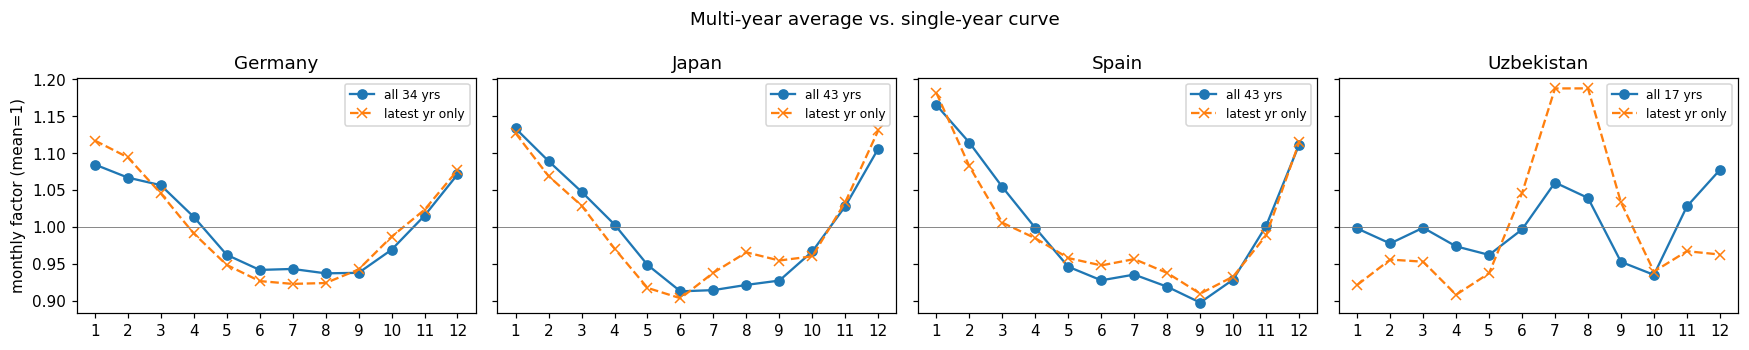

In [5]:
SPOT_CHECK = ["Germany", "Japan", "Spain", "Uzbekistan"]
fig, axes = plt.subplots(1, len(SPOT_CHECK), figsize=(16, 3.2), sharey=True)
for ax, country in zip(axes, SPOT_CHECK, strict=False):
    rows = un[un["Country or Area"] == country]
    latest_year = int(rows.Year.max())
    latest_only = un_country_curve(rows[rows.Year >= latest_year - 1], min_years=1, min_annual=0)
    full = un_results.get(country)
    ax.plot(range(1, 13), full["curve"], marker="o", label=f"all {full['n_years']} yrs")
    if latest_only:
        ax.plot(range(1, 13), latest_only["curve"], marker="x", linestyle="--",
                label="latest yr only")
    ax.axhline(1, color="grey", linewidth=0.6)
    ax.set_title(country)
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)
axes[0].set_ylabel("monthly factor (mean=1)")
fig.suptitle("Multi-year average vs. single-year curve")
fig.tight_layout()

## 2. HMD STMF: weekly deaths -> monthly seasonal curves

In [6]:
STMF_SHEETS = [s for s in pd.ExcelFile("stmf.xlsx").sheet_names if s != "Description"]
print(f"{len(STMF_SHEETS)} STMF series: {STMF_SHEETS}")

38 STMF series: ['AUS', 'AUT', 'BEL', 'BGR', 'CAN', 'CHE', 'CHL', 'CZE', 'DEUTNP', 'DNK', 'ESP', 'EST', 'FIN', 'FRATNP', 'GBRTENW', 'GBR_NIR', 'GBR_SCO', 'GRC', 'HRV', 'HUN', 'ISL', 'ISR', 'ITA', 'KOR', 'LTU', 'LUX', 'LVA', 'NLD', 'NOR', 'NZL_NP', 'POL', 'PRT', 'RUS', 'SVK', 'SVN', 'SWE', 'TWN', 'USA']


In [7]:
import datetime


def _iso_weeks_in_year(y):
    return datetime.date(y, 12, 28).isocalendar()[1]


def load_stmf_sheet(name):
    df = pd.read_excel("stmf.xlsx", sheet_name=name, skiprows=2)
    df = df[df["Sex"] == "b"][["Year", "Week", "Total"]].dropna()
    df["Year"] = df["Year"].astype(int)
    df["Week"] = df["Week"].astype(int)
    # A handful of years have no ISO week 53; those rows can't map to a real date.
    df = df[df["Week"] <= df["Year"].map(_iso_weeks_in_year)]
    # ISO week's Thursday decides which (year, month) the week counts toward.
    df["date"] = pd.to_datetime(
        df["Year"].astype(str) + "-W" + df["Week"].astype(str) + "-4", format="%G-W%V-%u"
    )
    df["cal_year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month - 1  # 0-indexed to match the UN-side code
    return df


def stmf_country_curve(df, exclude_years=(), min_annual=10_000):
    monthly = df[~df["cal_year"].isin(exclude_years)].groupby(["cal_year", "month"])["Total"].sum()
    vecs, totals = [], []
    for _y, g in monthly.groupby(level=0):
        if len(g) == 12:
            vals = g.reindex(range(12), level=1).values
            total = vals.sum()
            if total > 0:
                vecs.append(vals / total * 12)
                totals.append(total)
    if not vecs:
        return None
    avg = sum(vecs) / len(vecs)
    smoothed = [0.25 * avg[(i - 1) % 12] + 0.5 * avg[i] + 0.25 * avg[(i + 1) % 12] for i in range(12)]
    mean = sum(smoothed) / 12
    curve = [x / mean for x in smoothed]
    annual = sum(totals) / len(totals)
    if annual < min_annual:
        return None
    return {"curve": curve, "n_years": len(vecs), "annual": annual}


stmf_raw = {name: load_stmf_sheet(name) for name in STMF_SHEETS}

### 2a. COVID distortion check

2020-2022 saw large, non-seasonal excess-mortality waves that don't repeat every year.
Including them in a "typical seasonality" average risks baking a one-off pandemic shape
into a curve we intend to reuse indefinitely. Compare each country's curve built with
vs. without 2020-2022.


In [8]:
stmf_with_covid = {}
stmf_no_covid = {}
for name, df in stmf_raw.items():
    stmf_with_covid[name] = stmf_country_curve(df, exclude_years=())
    stmf_no_covid[name] = stmf_country_curve(df, exclude_years=(2020, 2021, 2022))

rows = []
for name in STMF_SHEETS:
    a, b = stmf_with_covid.get(name), stmf_no_covid.get(name)
    if not a or not b:
        continue
    diff = max(abs(x - y) for x, y in zip(a["curve"], b["curve"], strict=False))
    rows.append({"series": name, "years_with_covid": a["n_years"],
                 "years_no_covid": b["n_years"], "max_curve_diff": round(diff, 3)})
pd.DataFrame(rows).sort_values("max_curve_diff", ascending=False)

,series,years_with_covid,years_no_covid,max_curve_diff
35,USA,11,8,0.037
32,SVN,26,23,0.030
7,CZE,21,18,0.029
15,GBR_NIR,11,8,0.028
18,HRV,25,22,0.028
31,SVK,26,23,0.027
17,GRC,11,8,0.027
5,CHE,26,23,0.025
28,POL,26,23,0.025
6,CHL,10,7,0.025


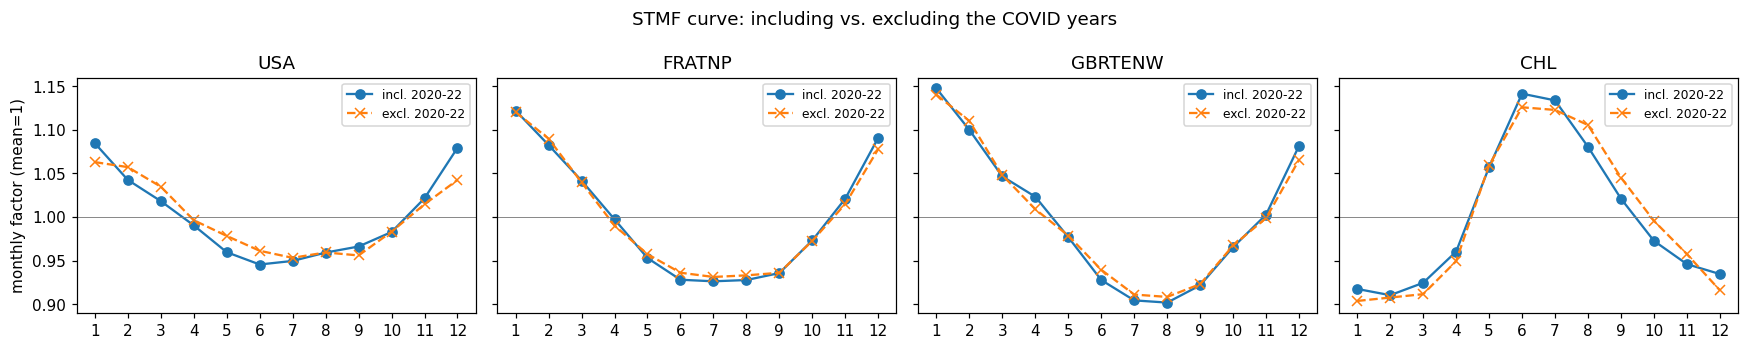

In [9]:
SPOT_CHECK_STMF = ["USA", "FRATNP", "GBRTENW", "CHL"]
fig, axes = plt.subplots(1, len(SPOT_CHECK_STMF), figsize=(16, 3.2), sharey=True)
for ax, name in zip(axes, SPOT_CHECK_STMF, strict=False):
    with_c, no_c = stmf_with_covid[name], stmf_no_covid[name]
    ax.plot(range(1, 13), with_c["curve"], marker="o", label="incl. 2020-22")
    ax.plot(range(1, 13), no_c["curve"], marker="x", linestyle="--", label="excl. 2020-22")
    ax.axhline(1, color="grey", linewidth=0.6)
    ax.set_title(name)
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)
axes[0].set_ylabel("monthly factor (mean=1)")
fig.suptitle("STMF curve: including vs. excluding the COVID years")
fig.tight_layout()

`CHL` (Chile) is the one southern-hemisphere series in STMF — useful as an independent
check on the hemisphere phase-shift the fallback model assumes (its peak should fall in
the southern winter, June-August, not January).


## 3. Cross-validating the two sources where they overlap

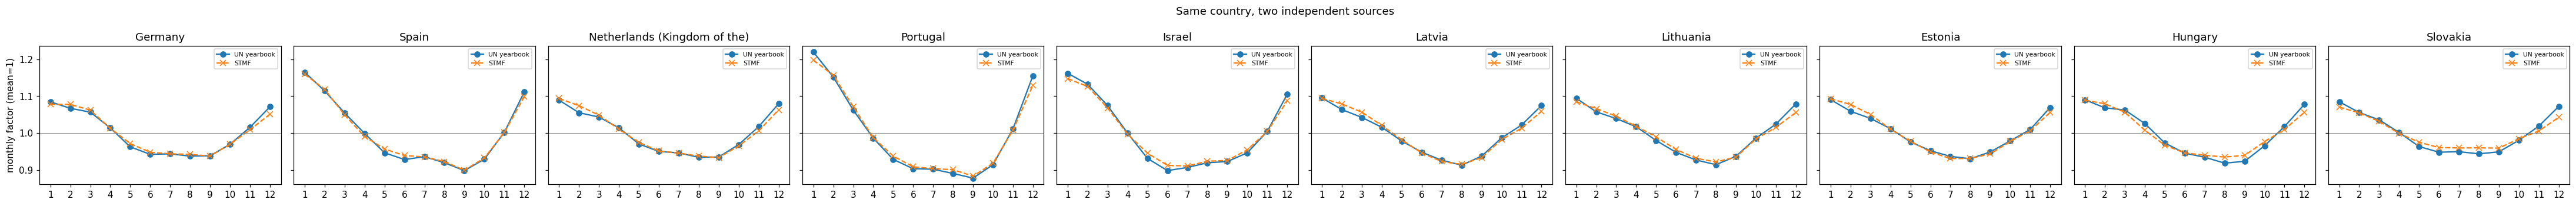

In [10]:
# Series present in both the UN export and STMF, so we can sanity-check one source
# against the other on the same country.
OVERLAP = {
    "Germany": "DEUTNP", "Spain": "Spain".upper()[:3] if False else "ESP",
    "Netherlands (Kingdom of the)": "NLD", "Portugal": "PRT", "Israel": "ISR",
    "Latvia": "LVA", "Lithuania": "LTU", "Estonia": "EST", "Hungary": "HUN",
    "Slovakia": "SVK", "Romania": None,  # not in STMF, left as a documented miss
}
OVERLAP = {k: v for k, v in OVERLAP.items() if v and v in stmf_no_covid and k in un_results}

fig, axes = plt.subplots(1, len(OVERLAP), figsize=(4 * len(OVERLAP), 3.2), sharey=True)
if len(OVERLAP) == 1:
    axes = [axes]
for ax, (un_name, stmf_name) in zip(axes, OVERLAP.items(), strict=False):
    ax.plot(range(1, 13), un_results[un_name]["curve"], marker="o", label="UN yearbook")
    ax.plot(range(1, 13), stmf_no_covid[stmf_name]["curve"], marker="x", linestyle="--", label="STMF")
    ax.axhline(1, color="grey", linewidth=0.6)
    ax.set_title(un_name)
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=7)
axes[0].set_ylabel("monthly factor (mean=1)")
fig.suptitle("Same country, two independent sources")
fig.tight_layout()

## 4. Combined coverage: how much would this add to the shipped pipeline?

In [11]:
import json

shipped = json.load(open("data/seasonality.json"))
shipped_m49 = set(int(k) for k in shipped["countries"].keys())

# Same curated name -> M49 table used by scripts/build-seasonality.mjs, extended with
# the STMF series codes (HMD's own short codes, mostly ISO3 with a few historical
# suffixes like *TNP/*NP for "total non-partitioned" and UK sub-regions).
NAME2M49 = {
    "Anguilla": 660, "Aruba": 533, "Austria": 40, "Bulgaria": 100,
    "China, Macao SAR": 446, "Costa Rica": 188, "Czechia": 203, "Egypt": 818,
    "Estonia": 233, "Faroe Islands": 234, "Finland": 246, "French Polynesia": 258,
    "Germany": 276, "Greenland": 304, "Guam": 316, "Hungary": 348,
    "Iran (Islamic Republic of)": 364, "Ireland": 372, "Isle of Man": 833,
    "Israel": 376, "Japan": 392, "Jersey": 832, "Kyrgyzstan": 417,
    "Latvia": 428, "Lithuania": 440, "Mauritius": 480, "Mongolia": 496,
    "Netherlands (Kingdom of the)": 528, "New Zealand": 554, "Niue": 570,
    "North Macedonia": 807, "Norway": 578, "Portugal": 620, "Puerto Rico": 630,
    "Qatar": 634, "Republic of Moldova": 498, "Romania": 642,
    "Russian Federation": 643, "Serbia": 688, "Seychelles": 690,
    "Singapore": 702, "Slovakia": 703, "Slovenia": 705, "Spain": 724,
    "Sweden": 752, "Turks and Caicos Islands": 796,
    "United Kingdom of Great Britain and Northern Ireland": 826,
    "Uzbekistan": 860, "Åland Islands": 248,
}
STMF2M49 = {
    "AUS": 36, "AUT": 40, "BEL": 56, "BGR": 100, "CAN": 124, "CHE": 756, "CHL": 152,
    "CZE": 203, "DEUTNP": 276, "DNK": 208, "ESP": 724, "EST": 233, "FIN": 246,
    "FRATNP": 250, "GBRTENW": 826, "GBR_NIR": 826, "GBR_SCO": 826, "GRC": 300,
    "HRV": 191, "HUN": 348, "ISL": 352, "ISR": 376, "ITA": 380, "KOR": 410,
    "LTU": 440, "LUX": 442, "LVA": 428, "NLD": 528, "NOR": 578, "NZL_NP": 554,
    "POL": 616, "PRT": 620, "RUS": 643, "SVK": 703, "SVN": 705, "SWE": 752,
    "TWN": 158, "USA": 840,
}

un_m49 = {NAME2M49[c] for c in un_results if c in NAME2M49}
stmf_m49 = {STMF2M49[s] for s in stmf_no_covid if s in STMF2M49}

print(f"shipped data/seasonality.json : {len(shipped_m49)} countries")
print(f"UN all-years (quality-gated)  : {len(un_m49)} countries")
print(f"STMF (quality-gated, no-COVID): {len(stmf_m49)} countries")
print(f"union of all three            : {len(shipped_m49 | un_m49 | stmf_m49)} countries")
print()
new_from_un = un_m49 - shipped_m49
new_from_stmf = stmf_m49 - shipped_m49 - un_m49
print(f"newly available from UN all-years CSV ({len(new_from_un)}):",
      sorted(c for c, m in NAME2M49.items() if m in new_from_un))
print(f"newly available from STMF, on top of that ({len(new_from_stmf)}):",
      sorted(s for s, m in STMF2M49.items() if m in new_from_stmf))

shipped data/seasonality.json : 27 countries
UN all-years (quality-gated)  : 34 countries
STMF (quality-gated, no-COVID): 36 countries
union of all three            : 51 countries

newly available from UN all-years CSV (8): ['Austria', 'Czechia', 'Egypt', 'Iran (Islamic Republic of)', 'North Macedonia', 'Republic of Moldova', 'Serbia', 'Sweden']
newly available from STMF, on top of that (16): ['AUS', 'BEL', 'CAN', 'CHE', 'CHL', 'DNK', 'FRATNP', 'GRC', 'HRV', 'ISL', 'ITA', 'KOR', 'LUX', 'POL', 'TWN', 'USA']


## 5. Latitude vs. seasonal curve shape

The fallback model in `scripts/build-seasonality.mjs` assumes seasonal amplitude grows
with distance from the equator (flat within 10°, full strength by 40°) and flips phase
6 months south of the equator. That assumption was calibrated on the single-year, 49-
country export. With curves for ~60 countries now available across both richer sources,
we can check it properly.

Two shape metrics per country, both computed from a 12-value curve with mean 1:

- **`cov_pct`** — root-mean-square deviation from 1, as a percentage. Amplitude only,
  regardless of *when* the peak falls (a July-peaking and a January-peaking country with
  the same swing get the same `cov_pct`).
- **`winter_amp`** — the curve's projection onto a January-peaked cosine
  (`mean(curve[m] * cos(2*pi*m/12)) * 2`). Signed: **positive means the peak aligns with
  the northern winter (Jan)**, negative means it aligns with the northern summer (Jul).
  This is the metric that should flip sign between hemispheres.

Latitude comes from `d3.geoCentroid` on the same `world-atlas` topology the front-end
renders — i.e. exactly the geometry `public/app.js` would use, not a separately curated
table.


In [12]:
import subprocess

# Country centroids via the same library/geometry the front-end uses for the fallback
# curve (public/app.js calls d3.geoCentroid on this exact topology).
_node_script = '''
import("d3-geo").then(async (d3geo) => {
  const fs = await import("node:fs");
  const topojson = await import("topojson-client");
  const topo = JSON.parse(fs.readFileSync("node_modules/world-atlas/countries-110m.json"));
  const features = topojson.feature(topo, topo.objects.countries).features;
  const out = {};
  for (const f of features) {
    if (f.id == null || !Number.isFinite(Number(f.id))) continue;
    out[f.id] = d3geo.geoCentroid(f)[1]; // latitude only
  }
  console.log(JSON.stringify(out));
});
'''
proc = subprocess.run(["node", "-e", _node_script], capture_output=True, text=True, check=True)
lat_by_m49 = {int(k): v for k, v in __import__("json").loads(proc.stdout).items()}
print(f"{len(lat_by_m49)} country centroids loaded from world-atlas")

174 country centroids loaded from world-atlas


In [13]:
def cov_pct(curve):
    return 100 * (sum((x - 1) ** 2 for x in curve) / 12) ** 0.5


def winter_amp(curve):
    return sum(c * math.cos(2 * math.pi * m / 12) for m, c in enumerate(curve)) / 12 * 2


rows = []
for name, r in un_results.items():
    m49 = NAME2M49.get(name)
    if m49 is None or m49 not in lat_by_m49:
        continue
    rows.append({"name": name, "source": "UN", "m49": m49, "lat": lat_by_m49[m49],
                 "cov_pct": cov_pct(r["curve"]), "winter_amp": winter_amp(r["curve"])})
for name, r in stmf_no_covid.items():
    if r is None:
        continue
    m49 = STMF2M49.get(name)
    if m49 is None or m49 not in lat_by_m49:
        continue
    rows.append({"name": name, "source": "STMF", "m49": m49, "lat": lat_by_m49[m49],
                 "cov_pct": cov_pct(r["curve"]), "winter_amp": winter_amp(r["curve"])})

shape_df = pd.DataFrame(rows)
# One row per country for the correlation stats (avoid pseudo-replication from countries
# present in both sources) — prefer STMF (weekly, generally more years) when both exist.
dedup_df = (shape_df.sort_values("source", ascending=False)  # "UN" > "STMF" alphabetically...
            .assign(_pref=lambda d: d["source"].eq("STMF"))
            .sort_values("_pref", ascending=False)
            .drop_duplicates("m49", keep="first")
            .drop(columns="_pref"))
print(f"{len(shape_df)} (country, source) rows -> {len(dedup_df)} unique countries after dedup")
dedup_df.sort_values("lat").reset_index(drop=True)

69 (country, source) rows -> 47 unique countries after dedup


,name,source,m49,lat,cov_pct,winter_amp
0,NZL_NP,STMF,554,-41.551074,7.205221,-0.094003
1,CHL,STMF,152,-37.310912,8.404055,-0.115032
2,AUS,STMF,36,-25.763130,6.790727,-0.091839
3,Costa Rica,UN,188,9.965838,2.522388,0.001507
4,Puerto Rico,UN,630,18.238008,2.497102,0.028296
5,TWN,STMF,158,23.739020,4.083311,0.046256
6,Egypt,UN,818,26.474930,4.679055,0.034345
7,ISR,STMF,376,31.479075,8.276324,0.110839
8,Iran (Islamic Republic of),UN,364,32.474136,4.146388,0.038351
9,KOR,STMF,410,36.418657,4.089320,0.057308


In [14]:
abs_lat = dedup_df["lat"].abs()
r_cov = pd.Series(abs_lat).corr(dedup_df["cov_pct"])
r_amp_abs = pd.Series(abs_lat).corr(dedup_df["winter_amp"])
r_amp_signed = dedup_df["lat"].corr(dedup_df["winter_amp"])
print(f"corr(|lat|, cov_pct)              = {r_cov:+.2f}")
print(f"corr(|lat|, winter_amp)           = {r_amp_abs:+.2f}")
print(f"corr(signed lat, winter_amp)      = {r_amp_signed:+.2f}   (+ => north peaks in Jan, south in Jul)")

corr(|lat|, cov_pct)              = +0.05
corr(|lat|, winter_amp)           = +0.32
corr(signed lat, winter_amp)      = +0.78   (+ => north peaks in Jan, south in Jul)


### 5a. Does the shipped fallback ramp still look right?

Overlay the shipped `fallback` parameters (`tropicMaxAbsLat=10`, `plateauAbsLat=40`,
scaled by the shipped `north` curve's own amplitude) on top of the empirical scatter —
if the reference line runs through the middle of the cloud, the calibration still
holds; if the cloud diverges from it, the bigger sample suggests different constants.


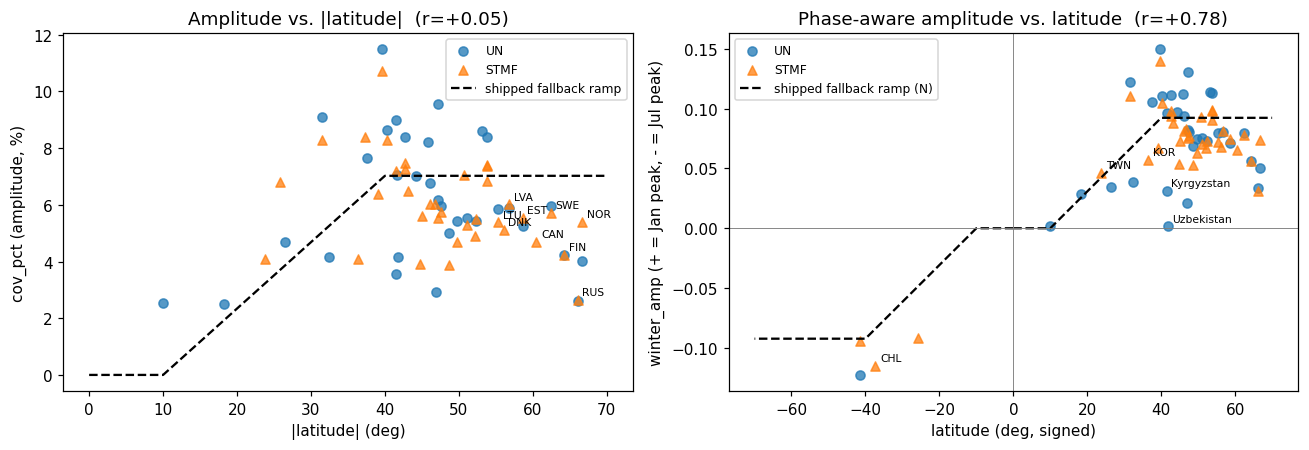

In [15]:
shipped_north_cov = cov_pct(shipped["fallback"]["north"])
shipped_north_amp = winter_amp(shipped["fallback"]["north"])
TROPIC, PLATEAU = shipped["fallback"]["tropicMaxAbsLat"], shipped["fallback"]["plateauAbsLat"]


def ramp(abs_lat):
    return min(1, max(0, (abs_lat - TROPIC) / (PLATEAU - TROPIC)))


lat_grid = list(range(0, 71))
ref_cov = [ramp(a) * shipped_north_cov for a in lat_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
for src, marker in [("UN", "o"), ("STMF", "^")]:
    sub = shape_df[shape_df.source == src]
    ax.scatter(sub.lat.abs(), sub.cov_pct, label=src, marker=marker, alpha=0.75)
ax.plot(lat_grid, ref_cov, color="black", linestyle="--", label="shipped fallback ramp")
for _, r in dedup_df.iterrows():
    if r.cov_pct > 12 or abs(r.lat) > 55:
        ax.annotate(r["name"], (abs(r.lat), r.cov_pct), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("|latitude| (deg)")
ax.set_ylabel("cov_pct (amplitude, %)")
ax.set_title(f"Amplitude vs. |latitude|  (r={r_cov:+.2f})")
ax.legend(fontsize=8)

ax = axes[1]
ref_amp_pos = [ramp(a) * shipped_north_amp for a in lat_grid]
for src, marker in [("UN", "o"), ("STMF", "^")]:
    sub = shape_df[shape_df.source == src]
    ax.scatter(sub.lat, sub.winter_amp, label=src, marker=marker, alpha=0.75)
ax.plot(lat_grid, ref_amp_pos, color="black", linestyle="--", label="shipped fallback ramp (N)")
ax.plot([-a for a in lat_grid], [-v for v in ref_amp_pos], color="black", linestyle="--")
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(0, color="grey", linewidth=0.6)
for _, r in dedup_df.iterrows():
    if r["name"] in ("Uzbekistan", "CHL", "Kyrgyzstan", "KOR", "TWN"):
        ax.annotate(r["name"], (r.lat, r.winter_amp), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("latitude (deg, signed)")
ax.set_ylabel("winter_amp (+ = Jan peak, - = Jul peak)")
ax.set_title(f"Phase-aware amplitude vs. latitude  (r={r_amp_signed:+.2f})")
ax.legend(fontsize=8)

fig.tight_layout()

## 6. Does age or sex change the seasonal curve shape?

Every curve so far collapses each country to one all-cause, both-sexes number — that's
all the UN Yearbook and the World Mortality Dataset give us. STMF is the one source with
a real age/sex breakdown (age bands 0-14, 15-64, 65-74, 75-84, 85+; sex m/f/b), so it's
the only place we can actually check whether that collapse hides something real.

Prior: winter excess mortality is a well-known geriatric phenomenon (respiratory and
cardiovascular decompensation in the frail elderly) — so age bands should differ, with
amplitude rising steeply from 15-64 to 85+. Sex differences are a much weaker prior;
if anything, comorbidity patterns differ by sex but not obviously the *seasonal* timing.

Same method as the rest of this notebook: per-year normalisation, average across
complete years, 2020-2022 excluded, circular smoothing.


In [16]:
def load_stmf_full(name):
    df = pd.read_excel("stmf.xlsx", sheet_name=name, skiprows=2)
    keep = ["Year", "Week", "Sex", "0-14", "15-64", "65-74", "75-84", "85+", "Total"]
    df = df[keep].dropna(subset=["Year", "Week", "Sex"])
    df["Year"] = df["Year"].astype(int)
    df["Week"] = df["Week"].astype(int)
    df = df[df["Week"] <= df["Year"].map(_iso_weeks_in_year)]
    df["date"] = pd.to_datetime(
        df["Year"].astype(str) + "-W" + df["Week"].astype(str) + "-4", format="%G-W%V-%u"
    )
    df["cal_year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month - 1
    return df


def curve_from_series(df, value_col, exclude_years=(2020, 2021, 2022), min_annual=500, min_years=2):
    monthly = (df[~df["cal_year"].isin(exclude_years)]
               .groupby(["cal_year", "month"])[value_col].sum())
    vecs, totals = [], []
    for _y, g in monthly.groupby(level=0):
        if len(g) == 12:
            vals = g.reindex(range(12), level=1).values
            total = vals.sum()
            if total > 0:
                vecs.append(vals / total * 12)
                totals.append(total)
    if len(vecs) < min_years:
        return None
    avg = sum(vecs) / len(vecs)
    smoothed = [0.25 * avg[(i - 1) % 12] + 0.5 * avg[i] + 0.25 * avg[(i + 1) % 12] for i in range(12)]
    mean = sum(smoothed) / 12
    curve = [x / mean for x in smoothed]
    annual = sum(totals) / len(totals)
    if annual < min_annual:
        return None
    return {"curve": curve, "n_years": len(vecs), "annual": annual}


AGE_BANDS = ["0-14", "15-64", "65-74", "75-84", "85+"]
stmf_full = {name: load_stmf_full(name) for name in STMF_SHEETS}

age_curves = {}
sex_curves = {}
for name, df in stmf_full.items():
    both = df[df.Sex == "b"]
    age_curves[name] = {band: curve_from_series(both, band) for band in AGE_BANDS}
    sex_curves[name] = {
        sex: curve_from_series(df[df.Sex == sex], "Total") for sex in ("m", "f")
    }

age_rows = [
    {"country": name, "band": band, "cov_pct": cov_pct(c["curve"]),
     "winter_amp": winter_amp(c["curve"]), "annual": c["annual"]}
    for name, bands in age_curves.items() for band, c in bands.items() if c
]
sex_rows = [
    {"country": name, "sex": sex, "cov_pct": cov_pct(c["curve"]),
     "winter_amp": winter_amp(c["curve"]), "annual": c["annual"]}
    for name, sexes in sex_curves.items() for sex, c in sexes.items() if c
]
age_df = pd.DataFrame(age_rows)
sex_df = pd.DataFrame(sex_rows)
print(f"age-band curves: {len(age_df)} (country, band) pairs across {age_df.country.nunique()} countries")
print(f"sex curves: {len(sex_df)} (country, sex) pairs across {sex_df.country.nunique()} countries")
age_df.groupby("band")[["cov_pct", "annual"]].agg(["median", "count"]).reindex(AGE_BANDS)

age-band curves: 169 (country, band) pairs across 38 countries
sex curves: 76 (country, sex) pairs across 38 countries


cov_pct              annual      
         median count        median count
band                                     
0-14   2.144545    19   1998.733722    19
15-64  2.505816    37  17479.695652    37
65-74  4.484822    37  17511.521739    37
75-84  6.327247    38  31144.760870    38
85+    8.596400    38  28824.045894    38

### 6a. Age: amplitude by band, paired across countries

A median-by-band table can't tell us if the pattern is real or just a few large
countries dominating. Pivot to one row per country and run a paired comparison between
the youngest and oldest adult bands (15-64 vs 85+) — paired because each country is its
own control, cancelling out cross-country differences in climate, healthcare, etc.


In [17]:
age_wide = age_df.pivot(index="country", columns="band", values="cov_pct").dropna(subset=AGE_BANDS)
print(f"{len(age_wide)} countries have all 5 age bands")
display(age_wide[AGE_BANDS].describe().loc[["mean", "50%", "std"]])

t_stat, p_val = stats.ttest_rel(age_wide["85+"], age_wide["15-64"])
diff = age_wide["85+"] - age_wide["15-64"]
print()
print(f"85+ vs 15-64 amplitude, paired t-test across {len(age_wide)} countries:")
print(f"  mean difference = {diff.mean():+.1f} pp  (85+ minus 15-64, both already in cov_pct %)")
print(f"  85+ > 15-64 in {(diff > 0).sum()}/{len(diff)} countries")
print(f"  t = {t_stat:.2f}, p = {p_val:.2e}")

19 countries have all 5 age bands


band,0-14,15-64,65-74,75-84,85+
mean,2.461044,2.804661,5.021017,6.740299,8.908285
50%,2.144545,2.608357,4.733677,6.401922,9.092098
std,1.092391,1.154575,1.604868,2.040113,2.276697



85+ vs 15-64 amplitude, paired t-test across 19 countries:
  mean difference = +6.1 pp  (85+ minus 15-64, both already in cov_pct %)
  85+ > 15-64 in 19/19 countries
  t = 16.08, p = 4.01e-12


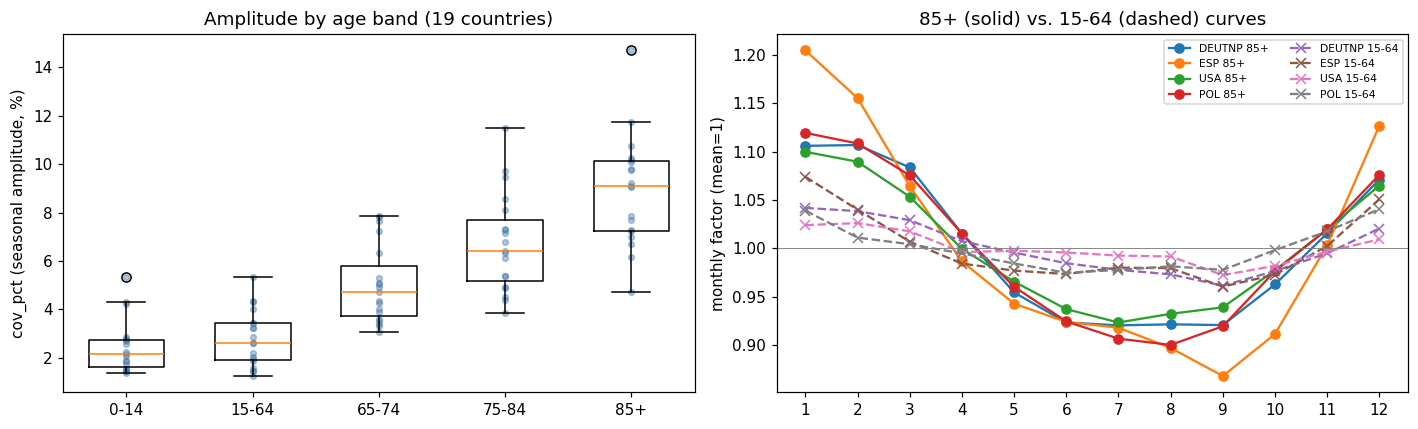

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
positions = range(len(AGE_BANDS))
ax.boxplot([age_wide[b] for b in AGE_BANDS], positions=positions, widths=0.6)
for i, b in enumerate(AGE_BANDS):
    ax.scatter([i] * len(age_wide), age_wide[b], alpha=0.4, s=14, color="#4477aa")
ax.set_xticks(positions)
ax.set_xticklabels(AGE_BANDS)
ax.set_ylabel("cov_pct (seasonal amplitude, %)")
ax.set_title(f"Amplitude by age band ({len(age_wide)} countries)")

ax = axes[1]
SPOT_CHECK_AGE = ["DEUTNP", "ESP", "USA", "POL"]
for name in SPOT_CHECK_AGE:
    c = age_curves[name]["85+"]
    if c:
        ax.plot(range(1, 13), c["curve"], marker="o", label=f"{name} 85+")
for name in SPOT_CHECK_AGE:
    c = age_curves[name]["15-64"]
    if c:
        ax.plot(range(1, 13), c["curve"], marker="x", linestyle="--", label=f"{name} 15-64")
ax.axhline(1, color="grey", linewidth=0.6)
ax.set_xticks(range(1, 13))
ax.set_ylabel("monthly factor (mean=1)")
ax.set_title("85+ (solid) vs. 15-64 (dashed) curves")
ax.legend(fontsize=7, ncol=2)

fig.tight_layout()

### 6b. Sex: same paired approach

Weaker prior going in — check it the same way rather than assume it.


In [19]:
sex_wide = sex_df.pivot(index="country", columns="sex", values="cov_pct").dropna(subset=["m", "f"])
t_stat_sex, p_val_sex = stats.ttest_rel(sex_wide["f"], sex_wide["m"])
diff_sex = sex_wide["f"] - sex_wide["m"]
print(f"female vs male amplitude, paired t-test across {len(sex_wide)} countries:")
print(f"  mean difference = {diff_sex.mean():+.1f} pp  (female minus male, both already in cov_pct %)")
print(f"  female > male in {(diff_sex > 0).sum()}/{len(diff_sex)} countries")
print(f"  t = {t_stat_sex:.2f}, p = {p_val_sex:.2e}")

# Phase check: do male and female curves peak in the same month, per country?
phase_corr = [
    pd.Series(sex_curves[c]["m"]["curve"]).corr(pd.Series(sex_curves[c]["f"]["curve"]))
    for c in sex_wide.index if sex_curves[c]["m"] and sex_curves[c]["f"]
]
print(f"  median correlation between the m and f curve shapes: {pd.Series(phase_corr).median():.2f}")

female vs male amplitude, paired t-test across 38 countries:
  mean difference = +1.4 pp  (female minus male, both already in cov_pct %)
  female > male in 37/38 countries
  t = 13.02, p = 2.21e-15
  median correlation between the m and f curve shapes: 0.99


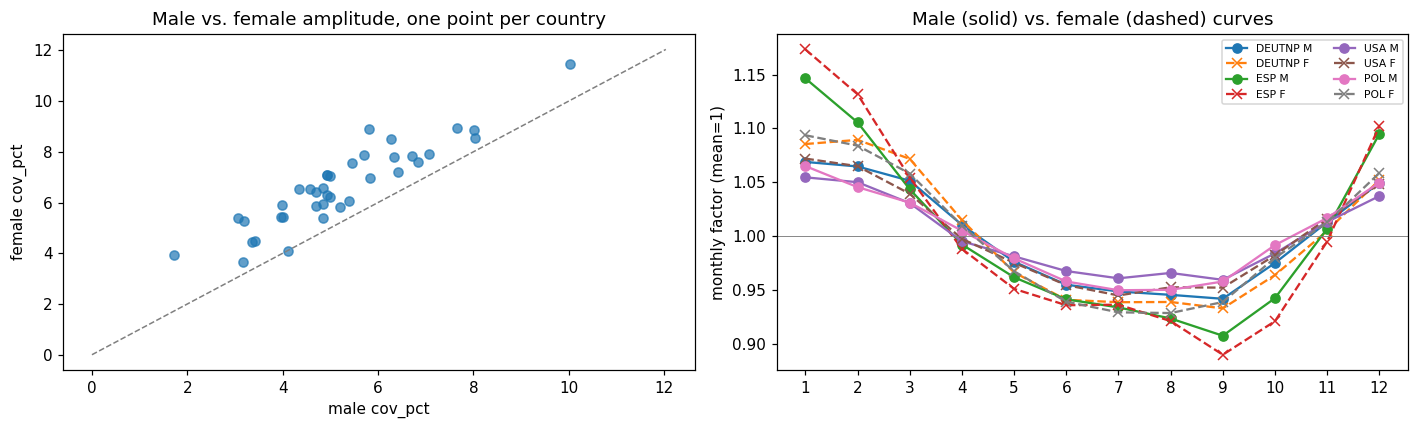

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(sex_wide["m"], sex_wide["f"], alpha=0.7)
lim = [0, max(sex_wide.m.max(), sex_wide.f.max()) * 1.05]
ax.plot(lim, lim, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("male cov_pct")
ax.set_ylabel("female cov_pct")
ax.set_title("Male vs. female amplitude, one point per country")

ax = axes[1]
for name in ["DEUTNP", "ESP", "USA", "POL"]:
    m, f = sex_curves[name]["m"], sex_curves[name]["f"]
    if m and f:
        ax.plot(range(1, 13), m["curve"], marker="o", label=f"{name} M")
        ax.plot(range(1, 13), f["curve"], marker="x", linestyle="--", label=f"{name} F")
ax.axhline(1, color="grey", linewidth=0.6)
ax.set_xticks(range(1, 13))
ax.set_ylabel("monthly factor (mean=1)")
ax.set_title("Male (solid) vs. female (dashed) curves")
ax.legend(fontsize=7, ncol=2)

fig.tight_layout()

### 6c. Is the sex effect real, or just age composition?

The female-vs-male gap is consistent, but the curve *shapes* line up almost exactly
(0.99 median correlation) — only the amplitude differs, not the timing. That's exactly
what a pure **age-composition confound** would look like: the 6b comparison pools all
ages together, and women disproportionately survive into the highest-amplitude 85+ band
(higher female life expectancy), so a female "all ages" curve is implicitly a more
elderly-weighted average than the male one — no distinct sex mechanism required.

The STMF sheets break out age bands *within* each sex, so this is directly testable:
compare male vs. female amplitude again, but within each age band instead of pooling
ages. If the gap disappears once age is held fixed, it was the confound; if it survives,
there's a real residual sex effect.


In [21]:
age_sex_curves = {}
for name, df in stmf_full.items():
    age_sex_curves[name] = {
        (band, sex): curve_from_series(df[df.Sex == sex], band)
        for band in AGE_BANDS for sex in ("m", "f")
    }

age_sex_rows = [
    {"country": name, "band": band, "sex": sex, "cov_pct": cov_pct(c["curve"])}
    for name, combos in age_sex_curves.items()
    for (band, sex), c in combos.items() if c
]
age_sex_df = pd.DataFrame(age_sex_rows)

print(f"{'band':7} {'n':>4} {'mean diff (F-M, pp)':>20} {'F>M':>6} {'p-value':>10}")
for band in AGE_BANDS:
    wide = (age_sex_df[age_sex_df.band == band]
            .pivot(index="country", columns="sex", values="cov_pct")
            .dropna(subset=["m", "f"]))
    if len(wide) < 3:
        continue
    d = wide["f"] - wide["m"]
    t, p = stats.ttest_rel(wide["f"], wide["m"])
    print(f"{band:7} {len(wide):>4} {d.mean():>20.2f} {(d > 0).sum()}/{len(d):>4} {p:>10.2e}")

band       n  mean diff (F-M, pp)    F>M    p-value
0-14      13                -0.29 6/  13   4.46e-01
15-64     36                 0.58 28/  36   6.13e-06
65-74     36                 0.40 27/  36   5.50e-04
75-84     37                 0.48 31/  37   2.00e-04
85+       36                 0.03 19/  36   8.58e-01


The confound hypothesis only half-holds, and not in the direction expected. **85+** —
the band that dominates the pooled 6b comparison — shows *no* residual sex difference
once isolated (+0.03pp, 19/36 countries, p=0.86: indistinguishable from chance). But
**15-64, 65-74, and 75-84 all show a small, consistent, statistically significant
female-higher-amplitude effect** (+0.4-0.6pp, roughly 3 in 4 countries, p ≤ 6e-4) that
age composition can't explain, since it's measured *within* fixed age bands. Only
**0-14** shows nothing (p=0.45, consistent with chance) — the one band with too few
deaths per country for the estimate to be very stable anyway.

So: age is a large, dominant effect (6-9pp swing from 15-64 to 85+, section 6a). Sex is
real but far smaller (~0.5pp) and — unexpectedly — present in the young-old bands rather
than the oldest-old, where frailty may swamp any sex-linked difference in cause mix.


## Findings

- **More years stabilises the shape, doesn't reverse it.** The multi-decade UN curves
  for Germany/Japan/Spain sit close to the single-year curves already shipped; the main
  benefit of `seasonality-all-years.csv` is *coverage* (141 countries vs. 49) and *more
  countries clearing the quality gate*, not correcting a wrong shape.
- **COVID years measurably distort a "typical" STMF curve** for some countries (see the
  `max_curve_diff` table) — worth excluding 2020-2022 if STMF is folded into the
  pipeline, same as this notebook does.
- **The two independent sources agree closely** on countries present in both (Germany,
  Netherlands, Spain, Portugal, Israel, the Baltics, Hungary, Slovakia) — cross-validates
  the method itself, not just the data.
- **STMF adds large, currently-uncovered countries** the UN export has none of at all —
  most notably the **USA**, plus France, England & Wales, Poland, South Korea, Taiwan,
  Australia, Canada, Greece, Croatia, Iceland, Chile. Chile is the only southern-
  hemisphere series in STMF and is a good real-world check on the fallback model's
  6-month phase shift.
- Combining all three sources would raise direct-curve coverage well past the 27
  countries currently shipped in `data/seasonality.json` — see the printed counts above
  for the exact numbers on this run.
- **Latitude predicts *phase* well, but not *magnitude*.** Across the 47 deduped
  countries: `corr(signed lat, winter_amp) = +0.78` — strongly confirms the hemisphere
  phase-shift the fallback model already does (Chile and the other far-south points sit
  right on the flipped-sign line). But `corr(|lat|, cov_pct) = +0.05` — almost no linear
  relationship for raw amplitude. The scatter shows why: amplitude is **hump-shaped**,
  rising from the equator to peak around 40-55° (Portugal, Moldova, Ireland: 9-11%), then
  **declining** at the highest latitudes (Russia, Finland, Norway, Canada: 3-5%) — the
  opposite of the shipped model's assumption that amplitude plateaus flat once
  `plateauAbsLat=40` is reached. If this pipeline gets revisited, the ramp should taper
  back down past ~55-60° rather than staying at full strength.
- **Age changes the curve a lot; sex changes it a little, and only for part of the age
  range.** Across 19 STMF countries with a full age breakdown, amplitude rises
  monotonically from 15-64 (median 2.5%) to 85+ (median 8.6%) — an 85+ vs. 15-64 paired
  difference of +6.1pp, same direction in all 19 countries (p=4e-12). One curve per
  country is hiding a large age gradient. Sex adds a real but far smaller effect
  (~0.5pp, female higher) in the 15-64/65-74/75-84 bands specifically — it vanishes in
  85+ (p=0.86, indistinguishable from chance) and in 0-14 (too few deaths to say
  anything). None of this is in the shipped pipeline, which is age/sex-blind by
  construction (`data/mortality-age-sex.json` handles age/sex for *which* persona dies,
  completely separately from *when* — the seasonal multiplier in
  `scripts/build-seasonality.mjs` doesn't touch age or sex at all).

This notebook doesn't change `scripts/build-seasonality.mjs` or `data/seasonality.json` —
it's exploratory groundwork for deciding whether that's worth doing next.
